STEP 0 : DATA VALIDATION

  Shape — X_train:(1479, 69)  X_val:(501, 69)  X_test:(563, 69)
  Missing values [X_train]: ✔ ไม่มี
  Missing values [X_val]: ✔ ไม่มี
  Missing values [X_test]: ✔ ไม่มี

  ✔ No data leakage — time-based split ถูกต้อง
    Train : 2016-02-12 → 2021-12-31
    Val   : 2022-01-03   → 2023-12-29
    Test  : 2024-01-02  → 2026-03-27

  Target (y_train) distribution:
    Mean  = 0.0416%
    Std   = 0.7022%
    Min   = -1.9661%
    Max   = 2.0649%
    Up days   = 760 (51.4%)
    Down days = 659 (44.6%)

STEP 1 : BASELINE XGBOOST

  Baseline results:
  [Train] RMSE=0.6997  MAE=0.5286  R²=0.0066  DirAcc=51.7%
  [Val  ] RMSE=0.7643  MAE=0.5861  R²=-0.0003  DirAcc=49.7%
  [Test ] RMSE=0.8335  MAE=0.6476  R²=-0.0381  DirAcc=53.6%

  Overfit gap (Train RMSE - Val RMSE) = -0.0647
  ⚠️  Gap สูง → มีแนวโน้ม overfit

STEP 2 : HYPERPARAMETER TUNING — Optuna + TimeSeriesSplit

  Running 80 trials × 5-fold TimeSeriesSplit ...

  ✔ Best CV RMSE : 0.7113
  Best params:
    n_estimato

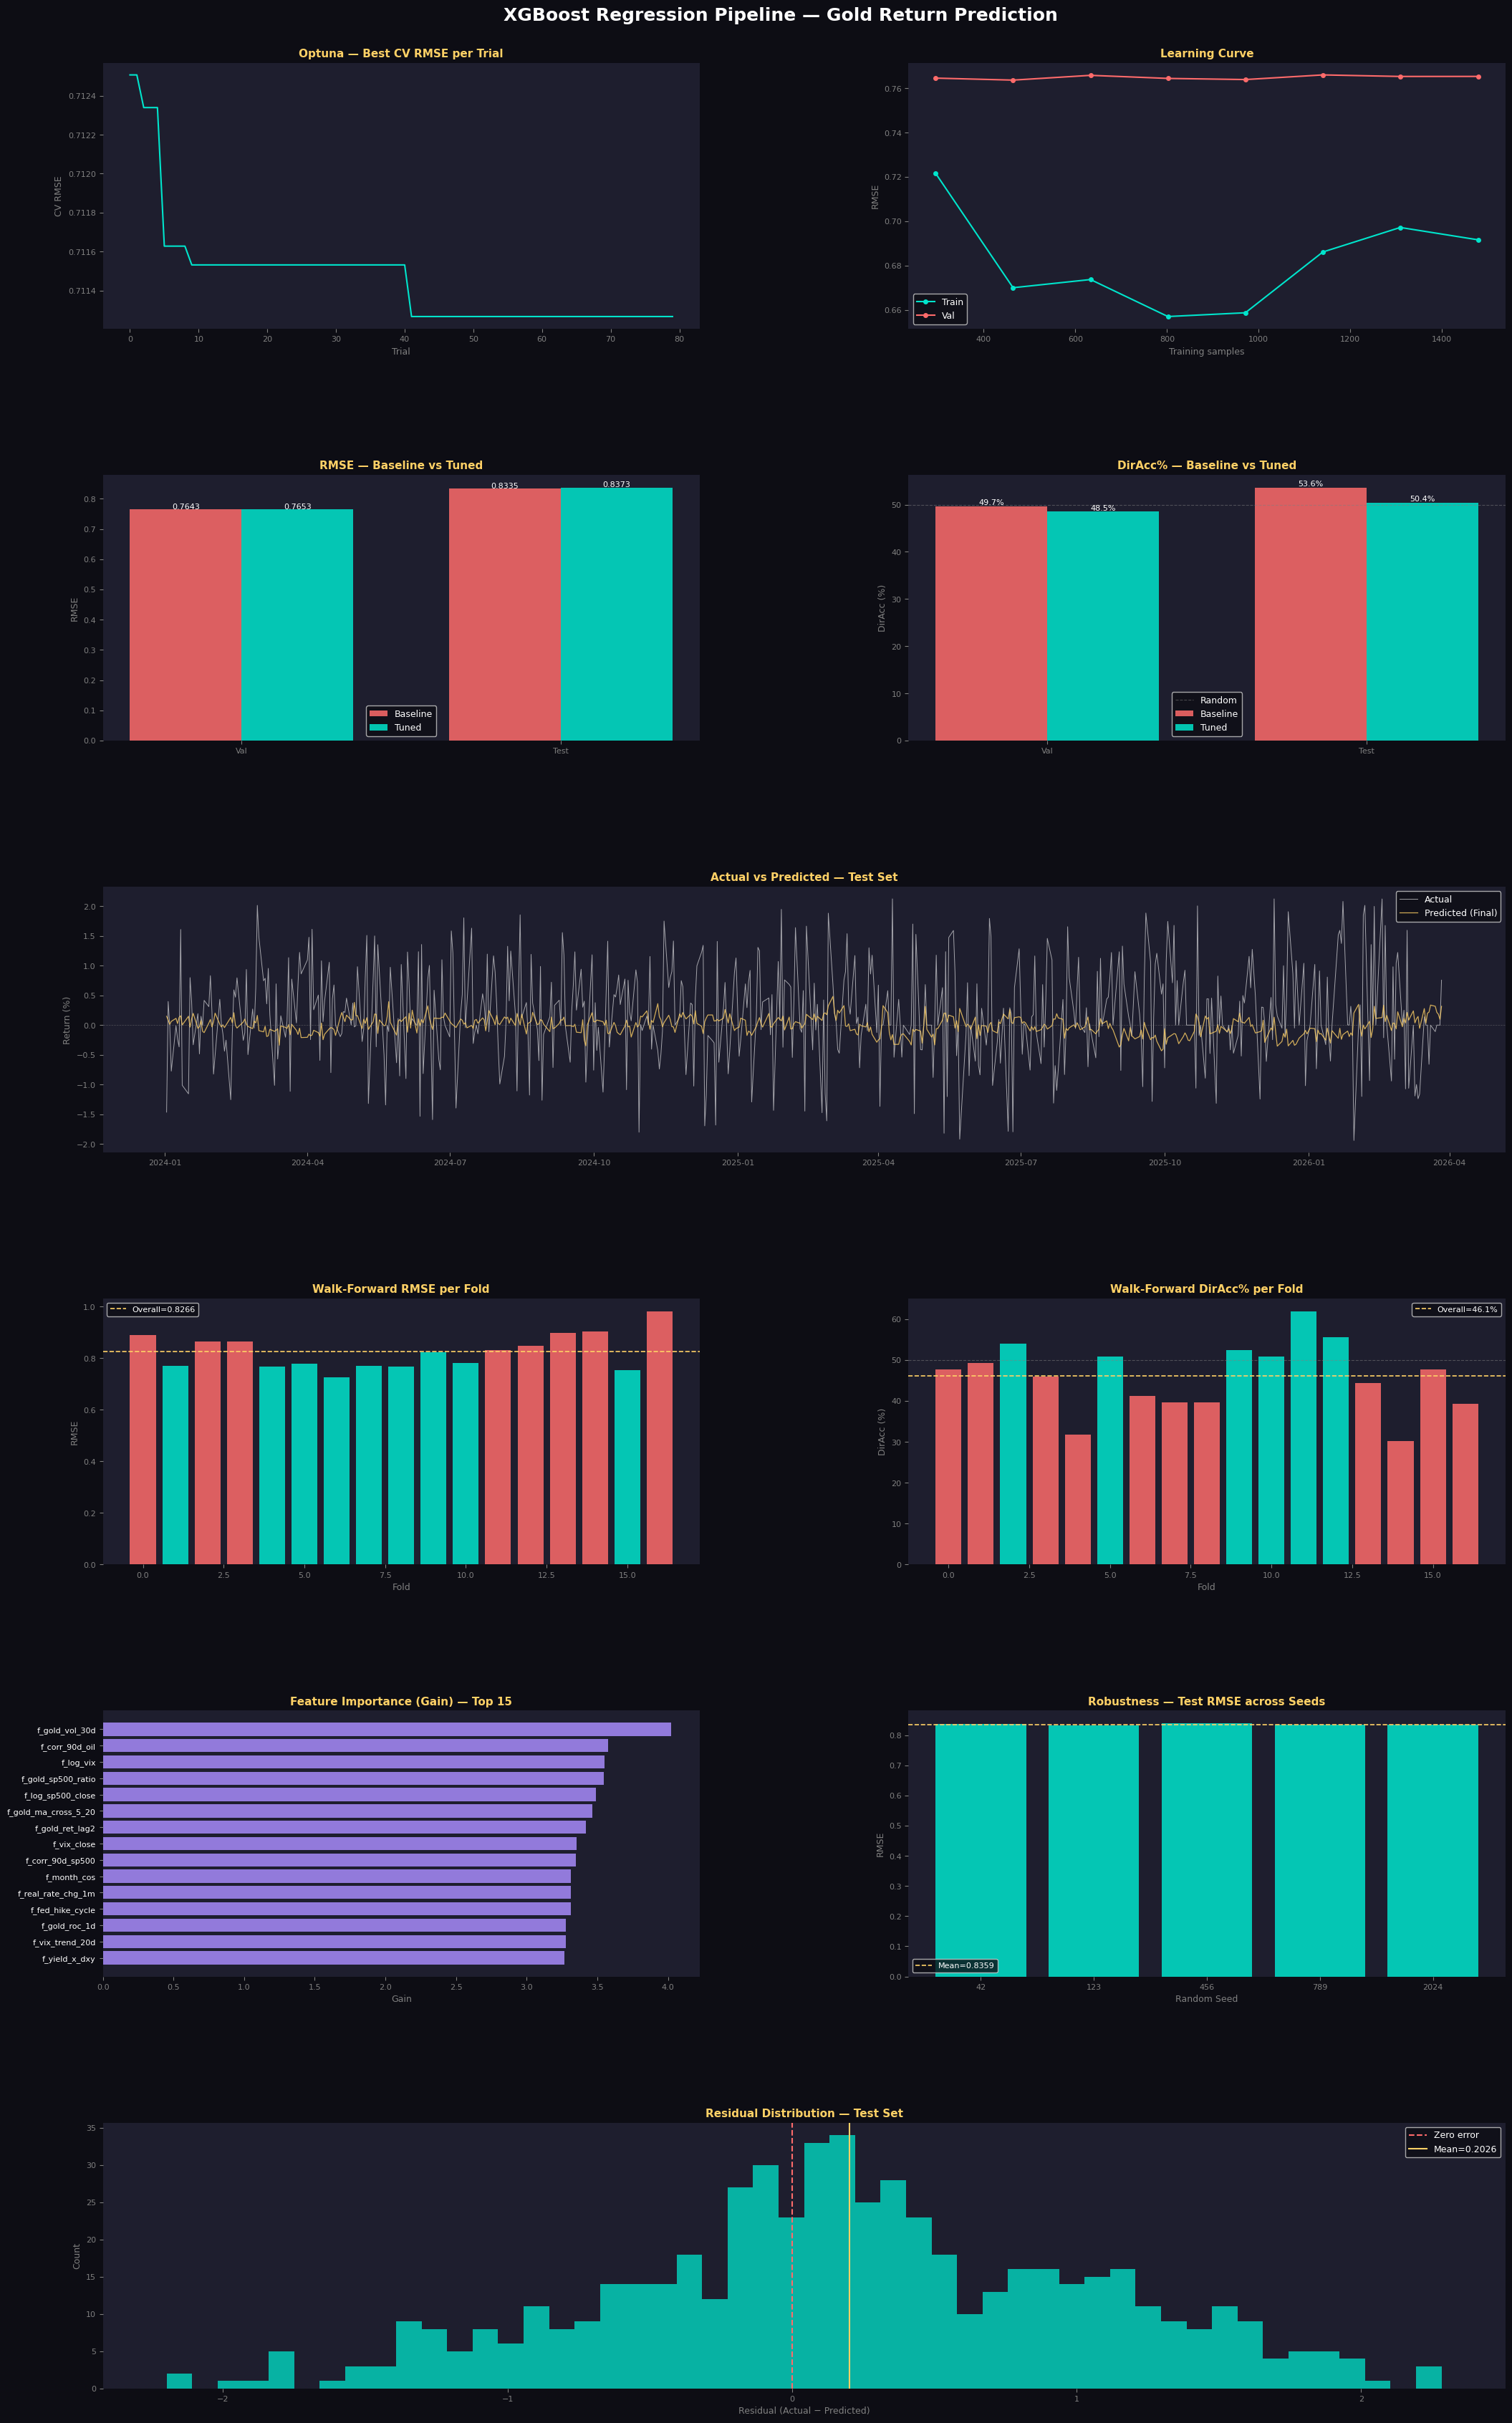


FINAL SUMMARY

Stage                            RMSE      MAE       R²    DirAcc%
--------------------------------------------------------------------
  Baseline                     0.8335   0.6476  -0.0381      53.6%
  Tuned (Train→Test)           0.8373   0.6497  -0.0477      50.4%
  Final (TrainVal→Test)        0.8595   0.6749  -0.1040      42.1%
  Walk-Forward Overall         0.8266      —    -0.0723      46.0%

Key takeaways:
  • Optuna ปรับ hyperparameter บน 80 trials × 5-fold TimeSeriesSplit
    → ป้องกัน leakage ระหว่าง tuning
  • Walk-Forward ใช้ expanding window (retrain ทุก 63 วัน)
    → จำลองการใช้งานจริงที่ไม่รู้อนาคต
  • Multi-seed test (5 seeds) วัดความเสถียรของโมเดล
  • Final model train บน Train+Val รวม → predict Test เพื่อใช้ data สูงสุด

DONE — Files saved to: ../../../data/processed/predictions/


In [2]:
# ============================================================
# XGBoost Regression Pipeline — Gold Next-Day Return Prediction
# Production-Ready | No Data Leakage | Walk-Forward Validated
# ============================================================
# โครงสร้าง:
#   Step 0 : Data Validation
#   Step 1 : Baseline XGBoost
#   Step 2 : Hyperparameter Tuning (Optuna + TimeSeriesSplit)
#   Step 3 : Bias-Variance Analysis
#   Step 4 : Walk-Forward Validation
#   Step 5 : Feature Importance + SHAP
#   Step 6 : Robustness Check (Multi-seed)
#   Step 7 : Final Model + Output
#   Step 8 : Summary
# ============================================================

import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings("ignore")

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# SHAP (optional — ติดตั้งด้วย pip install shap)
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("[INFO] ไม่พบ shap library — ข้าม SHAP analysis (pip install shap)")

# ── Style
FIG_COLOR  = "#0D0D14"
ACCENT1    = "#00E5CC"
ACCENT2    = "#FF6B6B"
ACCENT3    = "#FFD166"
ACCENT4    = "#A78BFA"
GRID_COLOR = "#1E1E2E"
plt.style.use("dark_background")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BASE = "../../../data/processed/splits/"
OUT  = "../../../data/processed/predictions/"
os.makedirs(OUT, exist_ok=True)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate(name, y_true, y_pred, verbose=True):
    """คำนวณ RMSE, MAE, R², DirAcc พร้อม print"""
    r   = rmse(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    da  = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    if verbose:
        print(f"  [{name}] RMSE={r:.4f}  MAE={mae:.4f}  R²={r2:.4f}  DirAcc={da:.1f}%")
    return {"name": name, "rmse": r, "mae": mae, "r2": r2, "dir_acc": da}

def check_no_leakage(X_train, X_val, X_test):
    """ตรวจสอบว่า index ไม่ overlap กัน (time-based split)"""
    assert X_train.index.max() < X_val.index.min(),  "❌ Train/Val overlap!"
    assert X_val.index.max()   < X_test.index.min(), "❌ Val/Test overlap!"
    print("  ✔ No data leakage — time-based split ถูกต้อง")
    print(f"    Train : {X_train.index.min().date()} → {X_train.index.max().date()}")
    print(f"    Val   : {X_val.index.min().date()}   → {X_val.index.max().date()}")
    print(f"    Test  : {X_test.index.min().date()}  → {X_test.index.max().date()}")

def styled_ax(ax, title):
    ax.set_facecolor(GRID_COLOR)
    ax.set_title(title, color=ACCENT3, fontsize=11, fontweight="bold")
    ax.tick_params(colors="gray", labelsize=8)
    ax.spines[:].set_visible(False)


# ============================================================
# STEP 0 : DATA VALIDATION
# ============================================================
print("=" * 60)
print("STEP 0 : DATA VALIDATION")
print("=" * 60)

X_train = pd.read_csv(BASE + "X_train.csv", parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv(BASE + "X_val.csv",   parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv(BASE + "X_test.csv",  parse_dates=["Date"], index_col="Date")
y_train = pd.read_csv(BASE + "y_train_reg.csv", parse_dates=["Date"], index_col="Date").squeeze()
y_val   = pd.read_csv(BASE + "y_val_reg.csv",   parse_dates=["Date"], index_col="Date").squeeze()
y_test  = pd.read_csv(BASE + "y_test_reg.csv",  parse_dates=["Date"], index_col="Date").squeeze()

# 0-A: Shape
print(f"\n  Shape — X_train:{X_train.shape}  X_val:{X_val.shape}  X_test:{X_test.shape}")

# 0-B: Missing values
for name, df in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
    n_miss = df.isnull().sum().sum()
    status = "✔ ไม่มี" if n_miss == 0 else f"❌ พบ {n_miss} ค่า"
    print(f"  Missing values [{name}]: {status}")

# 0-C: Leakage check
print()
check_no_leakage(X_train, X_val, X_test)

# 0-D: Target distribution
print(f"\n  Target (y_train) distribution:")
print(f"    Mean  = {y_train.mean():.4f}%")
print(f"    Std   = {y_train.std():.4f}%")
print(f"    Min   = {y_train.min():.4f}%")
print(f"    Max   = {y_train.max():.4f}%")
print(f"    Up days   = {(y_train > 0).sum()} ({(y_train > 0).mean()*100:.1f}%)")
print(f"    Down days = {(y_train < 0).sum()} ({(y_train < 0).mean()*100:.1f}%)")

# รวม train+val สำหรับ Optuna
X_tv = pd.concat([X_train, X_val])
y_tv = pd.concat([y_train, y_val])


# ============================================================
# STEP 1 : BASELINE XGBOOST
# ============================================================
print("\n" + "=" * 60)
print("STEP 1 : BASELINE XGBOOST")
print("=" * 60)

baseline_params = {
    "n_estimators"    : 500,
    "learning_rate"   : 0.05,
    "max_depth"       : 4,
    "min_child_weight": 5,
    "subsample"       : 0.8,
    "colsample_bytree": 0.7,
    "reg_alpha"       : 0.1,
    "reg_lambda"      : 1.0,
    "gamma"           : 0.0,
    "objective"       : "reg:squarederror",
    "eval_metric"     : "rmse",
    "tree_method"     : "hist",
    "random_state"    : RANDOM_STATE,
    "n_jobs"          : -1,
    "verbosity"       : 0,
}

# [FIX] ย้าย early_stopping_rounds มาไว้ตอนสร้างโมเดล
baseline_model = xgb.XGBRegressor(**baseline_params, early_stopping_rounds=50)
baseline_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print("\n  Baseline results:")
m_base_train = evaluate("Train", y_train, baseline_model.predict(X_train))
m_base_val   = evaluate("Val  ", y_val,   baseline_model.predict(X_val))
m_base_test  = evaluate("Test ", y_test,  baseline_model.predict(X_test))

overfit_gap = m_base_train["rmse"] - m_base_val["rmse"]
print(f"\n  Overfit gap (Train RMSE - Val RMSE) = {overfit_gap:.4f}")
if abs(overfit_gap) > 0.05:
    print("  ⚠️  Gap สูง → มีแนวโน้ม overfit")
else:
    print("  ✔  Gap ต่ำ → Bias-Variance สมดุล")


# ============================================================
# STEP 2 : HYPERPARAMETER TUNING (OPTUNA)
# ============================================================
print("\n" + "=" * 60)
print("STEP 2 : HYPERPARAMETER TUNING — Optuna + TimeSeriesSplit")
print("=" * 60)

N_SPLITS = 5
N_TRIALS = 80
tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=1)


def xgb_objective(trial):
    """
    Objective function สำหรับ Optuna
    ใช้ TimeSeriesSplit เพื่อป้องกัน leakage ระหว่าง tuning
    """
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 100, 1500),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 2, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma"           : trial.suggest_float("gamma", 0.0, 5.0),
        "objective"       : "reg:squarederror",
        "eval_metric"     : "rmse",
        "tree_method"     : "hist",
        "random_state"    : RANDOM_STATE,
        "n_jobs"          : -1,
        "verbosity"       : 0,
    }

    cv_scores = []
    for fold_idx, (tr_idx, vl_idx) in enumerate(tscv.split(X_tv)):
        X_f_tr = X_tv.iloc[tr_idx];  X_f_vl = X_tv.iloc[vl_idx]
        y_f_tr = y_tv.iloc[tr_idx];  y_f_vl = y_tv.iloc[vl_idx]

        # [FIX] ย้าย early_stopping_rounds มาไว้ตอนสร้างโมเดล
        model = xgb.XGBRegressor(**params, early_stopping_rounds=30)
        model.fit(
            X_f_tr, y_f_tr,
            eval_set=[(X_f_vl, y_f_vl)],
            verbose=False,
        )
        fold_rmse = rmse(y_f_vl, model.predict(X_f_vl))
        cv_scores.append(fold_rmse)

        # Pruning — ตัด trial ที่แย่กว่า median ออกเร็วๆ
        trial.report(np.mean(cv_scores), fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(cv_scores)


print(f"\n  Running {N_TRIALS} trials × {N_SPLITS}-fold TimeSeriesSplit ...")
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)
study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)

best_params = study.best_params.copy()
best_params.update({
    "objective" : "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs"     : -1,
    "verbosity"  : 0,
})

print(f"\n  ✔ Best CV RMSE : {study.best_value:.4f}")
print(f"  Best params:")
for k, v in best_params.items():
    if k not in ["objective", "eval_metric", "tree_method", "random_state", "n_jobs", "verbosity"]:
        print(f"    {k:<22}: {v}")


# ============================================================
# STEP 3 : BIAS-VARIANCE ANALYSIS
# ============================================================
print("\n" + "=" * 60)
print("STEP 3 : BIAS-VARIANCE ANALYSIS")
print("=" * 60)

# Retrain tuned model
# [FIX] ย้าย early_stopping_rounds มาไว้ตอนสร้างโมเดล
tuned_model = xgb.XGBRegressor(**best_params, early_stopping_rounds=50)
tuned_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print("\n  Tuned model results:")
m_tuned_train = evaluate("Train", y_train, tuned_model.predict(X_train))
m_tuned_val   = evaluate("Val  ", y_val,   tuned_model.predict(X_val))
m_tuned_test  = evaluate("Test ", y_test,  tuned_model.predict(X_test))

gap_tuned = m_tuned_train["rmse"] - m_tuned_val["rmse"]
print(f"\n  Overfit gap (Tuned) = {gap_tuned:.4f}")

print("\n  Improvement vs Baseline:")
print(f"    Val  RMSE : {m_base_val['rmse']:.4f} → {m_tuned_val['rmse']:.4f}  "
      f"({'↓' if m_tuned_val['rmse'] < m_base_val['rmse'] else '↑'} "
      f"{abs(m_tuned_val['rmse'] - m_base_val['rmse']):.4f})")
print(f"    Test RMSE : {m_base_test['rmse']:.4f} → {m_tuned_test['rmse']:.4f}  "
      f"({'↓' if m_tuned_test['rmse'] < m_base_test['rmse'] else '↑'} "
      f"{abs(m_tuned_test['rmse'] - m_base_test['rmse']):.4f})")
print(f"    Val  DirAcc: {m_base_val['dir_acc']:.1f}% → {m_tuned_val['dir_acc']:.1f}%")
print(f"    Test DirAcc: {m_base_test['dir_acc']:.1f}% → {m_tuned_test['dir_acc']:.1f}%")

# Learning curve (train size vs RMSE)
print("\n  คำนวณ Learning Curve ...")
train_sizes = np.linspace(0.2, 1.0, 8)
lc_train_rmse, lc_val_rmse = [], []
for frac in train_sizes:
    n = max(50, int(len(X_train) * frac))
    X_sub = X_train.iloc[:n];  y_sub = y_train.iloc[:n]
    # [FIX] ย้าย early_stopping_rounds มาไว้ตอนสร้างโมเดล
    m = xgb.XGBRegressor(**best_params, early_stopping_rounds=30)
    m.fit(X_sub, y_sub, eval_set=[(X_val, y_val)], verbose=False)
    lc_train_rmse.append(rmse(y_sub, m.predict(X_sub)))
    lc_val_rmse.append(rmse(y_val, m.predict(X_val)))


# ============================================================
# STEP 4 : WALK-FORWARD VALIDATION
# ============================================================
print("\n" + "=" * 60)
print("STEP 4 : WALK-FORWARD VALIDATION")
print("=" * 60)

WF_INIT = len(X_train)
WF_STEP = 63   # ~1 quarter

X_full = pd.concat([X_train, X_val, X_test])
y_full = pd.concat([y_train, y_val, y_test])

wf_rows, wf_fold_metrics = [], []
start = WF_INIT
fold  = 0

print(f"\n  Initial train : {WF_INIT} rows  |  Step : {WF_STEP}  |  Total : {len(X_full)}")

while start < len(X_full):
    end = min(start + WF_STEP, len(X_full))

    X_wf_tr = X_full.iloc[:start];   y_wf_tr = y_full.iloc[:start]
    X_wf_te = X_full.iloc[start:end]; y_wf_te = y_full.iloc[start:end]

    wf_model = xgb.XGBRegressor(**best_params)
    wf_model.fit(X_wf_tr, y_wf_tr, verbose=False)

    preds = wf_model.predict(X_wf_te)
    fold_rmse = rmse(y_wf_te, preds)
    fold_da   = np.mean(np.sign(y_wf_te) == np.sign(preds)) * 100

    wf_fold_metrics.append({
        "fold"    : fold,
        "start"   : X_wf_te.index[0].date(),
        "end"     : X_wf_te.index[-1].date(),
        "n_rows"  : len(y_wf_te),
        "RMSE"    : round(fold_rmse, 4),
        "DirAcc%" : round(fold_da, 2),
    })

    for i, date in enumerate(X_wf_te.index):
        wf_rows.append({
            "Date"         : date,
            "fold"         : fold,
            "actual_return": float(y_wf_te.iloc[i]),
            "pred_return"  : float(preds[i]),
        })

    fold += 1;  start = end

wf_df   = pd.DataFrame(wf_rows).set_index("Date")
fold_df = pd.DataFrame(wf_fold_metrics)

wf_overall_rmse = rmse(wf_df["actual_return"], wf_df["pred_return"])
wf_overall_da   = np.mean(np.sign(wf_df["actual_return"]) == np.sign(wf_df["pred_return"])) * 100
wf_overall_r2   = r2_score(wf_df["actual_return"], wf_df["pred_return"])

print("\n  Walk-Forward fold results:")
print(fold_df.to_string(index=False))
print(f"\n  Overall RMSE   = {wf_overall_rmse:.4f}")
print(f"  Overall DirAcc = {wf_overall_da:.1f}%")
print(f"  Overall R²     = {wf_overall_r2:.4f}")


# ============================================================
# STEP 5 : FEATURE IMPORTANCE + SHAP
# ============================================================
print("\n" + "=" * 60)
print("STEP 5 : FEATURE IMPORTANCE + SHAP")
print("=" * 60)

# XGBoost built-in importance (gain)
importance_gain = tuned_model.get_booster().get_score(importance_type="gain")
fi_df = (
    pd.DataFrame.from_dict(importance_gain, orient="index", columns=["gain"])
    .sort_values("gain", ascending=False)
    .head(20)
)
print(f"\n  Top 10 features (gain):")
print(fi_df.head(10).to_string())

# SHAP
shap_values_arr = None
if HAS_SHAP:
    print("\n  คำนวณ SHAP values ...")
    explainer = shap.TreeExplainer(tuned_model)
    shap_values_arr = explainer.shap_values(X_test)
    shap_df = pd.DataFrame(
        np.abs(shap_values_arr).mean(axis=0),
        index=X_test.columns,
        columns=["mean_abs_shap"]
    ).sort_values("mean_abs_shap", ascending=False)
    print(f"\n  Top 10 features (SHAP):")
    print(shap_df.head(10).to_string())
else:
    print("  [SKIP] ไม่มี shap — ใช้ XGBoost gain importance แทน")


# ============================================================
# STEP 6 : ROBUSTNESS CHECK (MULTI-SEED)
# ============================================================
print("\n" + "=" * 60)
print("STEP 6 : ROBUSTNESS CHECK — Multi-Seed")
print("=" * 60)

seeds       = [42, 123, 456, 789, 2024]
seed_results = []

for seed in seeds:
    p = best_params.copy()
    p["random_state"] = seed
    # [FIX] ย้าย early_stopping_rounds มาไว้ตอนสร้างโมเดล
    m = xgb.XGBRegressor(**p, early_stopping_rounds=50)
    m.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)
    r_val  = rmse(y_val,  m.predict(X_val))
    r_test = rmse(y_test, m.predict(X_test))
    da_test = np.mean(np.sign(y_test) == np.sign(m.predict(X_test))) * 100
    seed_results.append({"seed": seed, "val_rmse": r_val,
                          "test_rmse": r_test, "test_diracc": da_test})

seed_df = pd.DataFrame(seed_results)
print("\n  Multi-seed results:")
print(seed_df.to_string(index=False))
print(f"\n  Val  RMSE  — Mean={seed_df['val_rmse'].mean():.4f}  Std={seed_df['val_rmse'].std():.4f}")
print(f"  Test RMSE  — Mean={seed_df['test_rmse'].mean():.4f}  Std={seed_df['test_rmse'].std():.4f}")
print(f"  Test DirAcc— Mean={seed_df['test_diracc'].mean():.1f}%  Std={seed_df['test_diracc'].std():.2f}%")

stability = "✔ เสถียร" if seed_df["test_rmse"].std() < 0.02 else "⚠️  ไม่เสถียร — ผล sensitive ต่อ seed"
print(f"\n  Stability : {stability}")


# ============================================================
# STEP 7 : FINAL MODEL + OUTPUT
# ============================================================
print("\n" + "=" * 60)
print("STEP 7 : FINAL MODEL + OUTPUT")
print("=" * 60)

# Retrain บน train+val รวมกัน (ใช้ทุก data ที่รู้ก่อน test)
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_tv, y_tv, verbose=False)

pred_test_final = final_model.predict(X_test)
m_final_test    = evaluate("Test (Final)", y_test, pred_test_final)

# Build output DataFrame
df_out = pd.DataFrame({
    "fold"         : "test",
    "actual_return": y_test.values,
    "pred_return"  : np.round(pred_test_final, 6),
    "correct_direction": (np.sign(y_test.values) == np.sign(pred_test_final)).astype(int),
}, index=X_test.index)

# เพิ่ม walk-forward output ด้วย
wf_df["correct_direction"] = (
    np.sign(wf_df["actual_return"]) == np.sign(wf_df["pred_return"])
).astype(int)

# Save
df_out.to_csv(OUT + "xgb_test_output.csv")
wf_df.to_csv(OUT + "xgb_wf_output.csv")
seed_df.to_csv(OUT + "xgb_robustness.csv", index=False)
fold_df.to_csv(OUT + "xgb_wf_folds.csv",  index=False)

print(f"\n  ✔ xgb_test_output.csv   ({len(df_out)} rows)")
print(f"  ✔ xgb_wf_output.csv     ({len(wf_df)} rows)")
print(f"  ✔ xgb_robustness.csv    ({len(seed_df)} seeds)")
print(f"  ✔ xgb_wf_folds.csv      ({len(fold_df)} folds)")


# ============================================================
# STEP 8 : VISUALIZATION
# ============================================================
print("\n" + "=" * 60)
print("STEP 8 : VISUALIZATION")
print("=" * 60)

fig = plt.figure(figsize=(22, 34), facecolor=FIG_COLOR)
fig.suptitle("XGBoost Regression Pipeline — Gold Return Prediction",
             fontsize=18, color="white", fontweight="bold", y=0.998)
gs = gridspec.GridSpec(6, 2, figure=fig, hspace=0.55, wspace=0.35,
                       left=0.07, right=0.96, top=0.975, bottom=0.02)

# P1: Optuna history
ax0 = fig.add_subplot(gs[0, 0])
styled_ax(ax0, "Optuna — Best CV RMSE per Trial")
trial_vals = [t.value for t in study.trials if t.value is not None]
ax0.plot(np.minimum.accumulate(trial_vals), color=ACCENT1, lw=1.5)
ax0.set_xlabel("Trial", color="gray", fontsize=9)
ax0.set_ylabel("CV RMSE", color="gray", fontsize=9)

# P2: Learning curve
ax1 = fig.add_subplot(gs[0, 1])
styled_ax(ax1, "Learning Curve")
xs = [int(f * len(X_train)) for f in train_sizes]
ax1.plot(xs, lc_train_rmse, color=ACCENT1, lw=1.5, marker="o", ms=4, label="Train")
ax1.plot(xs, lc_val_rmse,   color=ACCENT2, lw=1.5, marker="o", ms=4, label="Val")
ax1.set_xlabel("Training samples", color="gray", fontsize=9)
ax1.set_ylabel("RMSE", color="gray", fontsize=9)
ax1.legend(fontsize=9, facecolor=FIG_COLOR, labelcolor="white")

# P3: Baseline vs Tuned comparison bar
ax2 = fig.add_subplot(gs[1, 0])
styled_ax(ax2, "RMSE — Baseline vs Tuned")
labels   = ["Val", "Test"]
baseline = [m_base_val["rmse"],  m_base_test["rmse"]]
tuned    = [m_tuned_val["rmse"], m_tuned_test["rmse"]]
x = np.arange(len(labels))
w = 0.35
bars1 = ax2.bar(x - w/2, baseline, w, color=ACCENT2, alpha=0.85, label="Baseline")
bars2 = ax2.bar(x + w/2, tuned,    w, color=ACCENT1, alpha=0.85, label="Tuned")
for b in list(bars1) + list(bars2):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002,
             f"{b.get_height():.4f}", ha="center", fontsize=8, color="white")
ax2.set_xticks(x);  ax2.set_xticklabels(labels, color="gray")
ax2.legend(fontsize=9, facecolor=FIG_COLOR, labelcolor="white")
ax2.set_ylabel("RMSE", color="gray", fontsize=9)

# P4: DirAcc comparison
ax3 = fig.add_subplot(gs[1, 1])
styled_ax(ax3, "DirAcc% — Baseline vs Tuned")
da_base  = [m_base_val["dir_acc"],  m_base_test["dir_acc"]]
da_tuned = [m_tuned_val["dir_acc"], m_tuned_test["dir_acc"]]
bars3 = ax3.bar(x - w/2, da_base,  w, color=ACCENT2, alpha=0.85, label="Baseline")
bars4 = ax3.bar(x + w/2, da_tuned, w, color=ACCENT1, alpha=0.85, label="Tuned")
for b in list(bars3) + list(bars4):
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
             f"{b.get_height():.1f}%", ha="center", fontsize=8, color="white")
ax3.axhline(50, color="gray", lw=0.8, linestyle="--", alpha=0.5, label="Random")
ax3.set_xticks(x);  ax3.set_xticklabels(labels, color="gray")
ax3.legend(fontsize=9, facecolor=FIG_COLOR, labelcolor="white")
ax3.set_ylabel("DirAcc (%)", color="gray", fontsize=9)

# P5: Actual vs Predicted (Test)
ax4 = fig.add_subplot(gs[2, :])
styled_ax(ax4, "Actual vs Predicted — Test Set")
ax4.plot(X_test.index, y_test.values,        color="white",  lw=0.7, alpha=0.6, label="Actual")
ax4.plot(X_test.index, pred_test_final,       color=ACCENT3,  lw=0.9, alpha=0.8, label="Predicted (Final)")
ax4.axhline(0, color="gray", lw=0.5, linestyle="--", alpha=0.5)
ax4.set_ylabel("Return (%)", color="gray", fontsize=9)
ax4.legend(fontsize=9, facecolor=FIG_COLOR, labelcolor="white")
ax4.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))

# P6: Walk-forward RMSE per fold
ax5 = fig.add_subplot(gs[3, 0])
styled_ax(ax5, "Walk-Forward RMSE per Fold")
colors_wf = [ACCENT1 if r < wf_overall_rmse else ACCENT2 for r in fold_df["RMSE"]]
ax5.bar(fold_df["fold"], fold_df["RMSE"], color=colors_wf, alpha=0.85)
ax5.axhline(wf_overall_rmse, color=ACCENT3, lw=1.2, linestyle="--",
            label=f"Overall={wf_overall_rmse:.4f}")
ax5.set_xlabel("Fold", color="gray", fontsize=9)
ax5.set_ylabel("RMSE", color="gray", fontsize=9)
ax5.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white")

# P7: Walk-forward DirAcc per fold
ax6 = fig.add_subplot(gs[3, 1])
styled_ax(ax6, "Walk-Forward DirAcc% per Fold")
colors_da = [ACCENT1 if d > 50 else ACCENT2 for d in fold_df["DirAcc%"]]
ax6.bar(fold_df["fold"], fold_df["DirAcc%"], color=colors_da, alpha=0.85)
ax6.axhline(50,            color="gray",  lw=0.8, linestyle="--", alpha=0.5)
ax6.axhline(wf_overall_da, color=ACCENT3, lw=1.2, linestyle="--",
            label=f"Overall={wf_overall_da:.1f}%")
ax6.set_xlabel("Fold", color="gray", fontsize=9)
ax6.set_ylabel("DirAcc (%)", color="gray", fontsize=9)
ax6.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white")

# P8: Feature importance (gain)
ax7 = fig.add_subplot(gs[4, 0])
styled_ax(ax7, "Feature Importance (Gain) — Top 15")
top15 = fi_df.head(15)
ax7.barh(range(len(top15)), top15["gain"].values[::-1], color=ACCENT4, alpha=0.85)
ax7.set_yticks(range(len(top15)))
ax7.set_yticklabels(top15.index[::-1], fontsize=8, color="white")
ax7.set_xlabel("Gain", color="gray", fontsize=9)

# P9: SHAP or robustness
ax8 = fig.add_subplot(gs[4, 1])
styled_ax(ax8, "Robustness — Test RMSE across Seeds")
ax8.bar(seed_df["seed"].astype(str), seed_df["test_rmse"],
        color=ACCENT1, alpha=0.85)
ax8.axhline(seed_df["test_rmse"].mean(), color=ACCENT3, lw=1.2,
            linestyle="--", label=f"Mean={seed_df['test_rmse'].mean():.4f}")
ax8.set_xlabel("Random Seed", color="gray", fontsize=9)
ax8.set_ylabel("RMSE", color="gray", fontsize=9)
ax8.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white")

# P10: Residual distribution
ax9 = fig.add_subplot(gs[5, :])
styled_ax(ax9, "Residual Distribution — Test Set")
residuals = y_test.values - pred_test_final
ax9.hist(residuals, bins=50, color=ACCENT1, alpha=0.75, edgecolor="none")
ax9.axvline(0,                   color=ACCENT2, lw=1.5, linestyle="--", label="Zero error")
ax9.axvline(np.mean(residuals),  color=ACCENT3, lw=1.5, linestyle="-",  label=f"Mean={np.mean(residuals):.4f}")
ax9.set_xlabel("Residual (Actual − Predicted)", color="gray", fontsize=9)
ax9.set_ylabel("Count", color="gray", fontsize=9)
ax9.legend(fontsize=9, facecolor=FIG_COLOR, labelcolor="white")

plt.savefig(OUT + "xgb_pipeline_result.png", dpi=140, bbox_inches="tight",
            facecolor=FIG_COLOR)
print("  ✔ Saved → xgb_pipeline_result.png")
plt.show()


# ============================================================
# STEP 9 : FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

summary = pd.DataFrame([
    {**{"stage": "Baseline"}, **{k: round(v, 4) if isinstance(v, float) else v
      for k, v in m_base_test.items()}},
    {**{"stage": "Tuned (Train→Test)"},   **{k: round(v, 4) if isinstance(v, float) else v
      for k, v in m_tuned_test.items()}},
    {**{"stage": "Final (TrainVal→Test)"}, **{k: round(v, 4) if isinstance(v, float) else v
      for k, v in m_final_test.items()}},
    {"stage": "Walk-Forward Overall",
     "rmse": round(wf_overall_rmse, 4),
     "dir_acc": round(wf_overall_da, 2),
     "r2": round(wf_overall_r2, 4)},
])

print(f"\n{'Stage':<28} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'DirAcc%':>10}")
print("-" * 68)
for _, row in summary.iterrows():
    mae_str = f"{row.get('mae', float('nan')):.4f}" if not pd.isna(row.get('mae', float('nan'))) else "  —  "
    print(f"  {row['stage']:<26} {row['rmse']:>8.4f} {mae_str:>8} "
          f"{row.get('r2', float('nan')):>8.4f} {row.get('dir_acc', float('nan')):>9.1f}%")

print(f"""
Key takeaways:
  • Optuna ปรับ hyperparameter บน {N_TRIALS} trials × {N_SPLITS}-fold TimeSeriesSplit
    → ป้องกัน leakage ระหว่าง tuning
  • Walk-Forward ใช้ expanding window (retrain ทุก {WF_STEP} วัน)
    → จำลองการใช้งานจริงที่ไม่รู้อนาคต
  • Multi-seed test ({len(seeds)} seeds) วัดความเสถียรของโมเดล
  • Final model train บน Train+Val รวม → predict Test เพื่อใช้ data สูงสุด
""")

print("=" * 60)
print("DONE — Files saved to:", OUT)
print("=" * 60)